In [10]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers
import os
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
import shutil
folders=os.listdir('data')
os.mkdir('train')
os.mkdir('test')
for i in folders:
    os.mkdir(f'train/{i}')
    os.mkdir(f'test/{i}')
Train_files=[]
Test_files=[]
for i in folders:
    all_files=os.listdir(f'data/{i}')
    Train_files,Test_files=train_test_split(all_files,test_size=0.2)
    for j in Train_files:
        shutil.copy(f'data/{i}/{j}',f'train/{i}')
    for j in Test_files:
        shutil.copy(f'data/{i}/{j}',f'test/{i}')

FileExistsError: [Errno 17] File exists: 'train'

In [2]:
os.listdir('data')

['Tomato__Target_Spot_1404',
 'Tomato_healthy_1591',
 'Tomato__Tomato_YellowLeaf__Curl_Virus_3209',
 'Tomato_Early_blight_1000',
 'Tomato_Late_blight_1909',
 'Tomato_Leaf_Mold_952',
 'Tomato__Tomato_mosaic_virus_373',
 'Tomato_Bacterial_spot_2127',
 'Tomato_Spider_mites_Two_spotted_spider_mite_1676',
 'Tomato_Septoria_leaf_spot_1771']

In [3]:
from keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest') 
training_set = train_datagen.flow_from_directory('train',
                                                 batch_size = 10
                                                 ,classes=os.listdir('data'))
test_datagen = ImageDataGenerator(rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest')
validation_set = test_datagen.flow_from_directory('test',
                                            batch_size = 10,classes=os.listdir('data'))

Found 12804 images belonging to 10 classes.
Found 3207 images belonging to 10 classes.


In [4]:
check_file='data/Tomato__Target_Spot_1404/002213fb-b620-4593-b9ac-6a6cc119b100___Com.G_TgS_FL 8360.JPG'
img = Image.open(check_file)
np.array(img).shape

(256, 256, 3)

In [5]:
tf.keras.backend.clear_session()
inputs=inputs = tf.keras.Input(shape=(256, 256, 3))
convo1= tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu')(inputs)
maxpool1=tf.keras.layers.MaxPool2D(pool_size=3, strides=2)(convo1)
convo2= tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu')(maxpool1)
maxpool2=tf.keras.layers.MaxPool2D(pool_size=3, strides=2)(convo2)
flatten=tf.keras.layers.Flatten()(maxpool2)
#dropout1=tf.keras.layers.Dropout(0.5)(flatten)
dence1=tf.keras.layers.Dense(100,activation='relu')(flatten)
#outputs=tf.keras.layers.Dense(10,activation='softmax')(dence1)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(dence1)
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer ='adam' , loss = 'binary_crossentropy', metrics = ['accuracy'])

In [6]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 254, 254, 64)      1792      
                                                                 
 max_pooling2d (MaxPooling2  (None, 126, 126, 64)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 124, 124, 32)      18464     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 61, 61, 32)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 119072)            0     

In [7]:
tf.keras.utils.plot_model(model, show_shapes=True,to_file='model.pdf')

In [8]:
history=model.fit(x = training_set, validation_data = validation_set, epochs = 5,steps_per_epoch=100)

Epoch 1/5
100/100 [==============================] - 154s 2s/step - loss: 0.4469 - accuracy: 0.8936 - val_loss: 0.3301 - val_accuracy: 0.9000
Epoch 2/5
100/100 [==============================] - 153s 2s/step - loss: 0.3285 - accuracy: 0.9000 - val_loss: 0.3263 - val_accuracy: 0.9000
Epoch 3/5
100/100 [==============================] - 153s 2s/step - loss: 0.3262 - accuracy: 0.9000 - val_loss: 0.3257 - val_accuracy: 0.9000
Epoch 4/5
100/100 [==============================] - 153s 2s/step - loss: 0.3257 - accuracy: 0.9000 - val_loss: 0.3256 - val_accuracy: 0.9000
Epoch 5/5
100/100 [==============================] - 157s 2s/step - loss: 0.3254 - accuracy: 0.9000 - val_loss: 0.3256 - val_accuracy: 0.9000


In [12]:
 print('The final accuracy of the model against validtion set: ',history.history['val_accuracy'][-1]*100,'%')

The final accuracy of the model against validtion set:  90.00000357627869 %


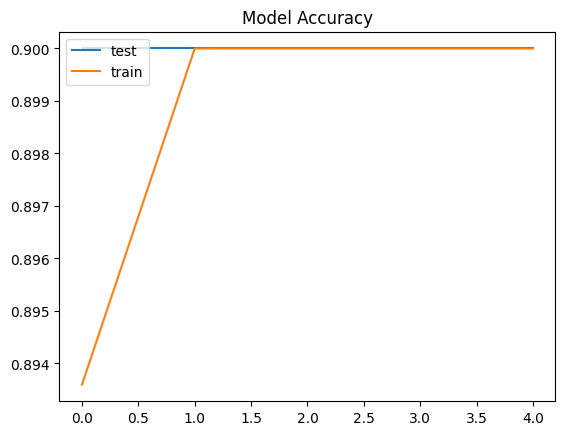

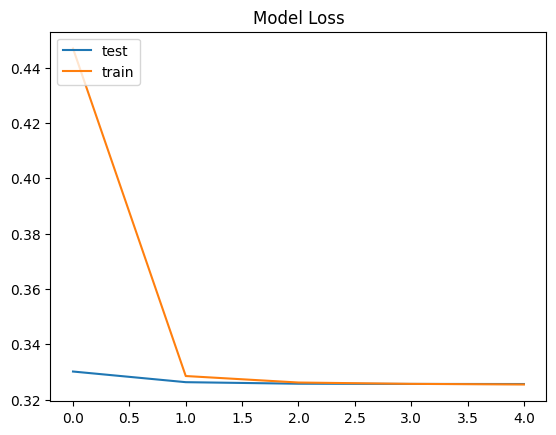

In [11]:
def plot(history):
    plt.plot(history.history['val_accuracy'])
    plt.plot(history.history['accuracy'])
    plt.title('Model Accuracy')
    plt.legend(['test', 'train'], loc='upper left')
    plt.savefig("accurecy.png")
    plt.show()
    plt.plot(history.history['val_loss'])
    plt.plot(history.history['loss'])
    plt.title('Model Loss')
    plt.legend(['test','train' ], loc='upper left')
    plt.savefig("loss.png")
    plt.show()
plot(history)